# IND320 Project Part 1

## Reservoir Data Analysis

This notebook contains the data analysis for Part 1 of the IND320 project. The dataset contains historical data on Norwegian reservoir levels and energy storage capacity.

The analysis includes data preparation, exploration and visualization of the reservoir data.

## 1. Importing and loading the data

First, Pandas is imported and the `reservoirs.csv` dataset is loaded into a DataFrame. The first five rows are displayed to get an initial overview of the dataset and its variables.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("reservoirs.csv")
df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 2. Renaming the columns

The original dataset contains Norwegian column names. To make the dataset easier to understand and work with, the columns are renamed using clear English names.

In [2]:
df = df.rename(columns={
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "year",
    "iso_uke": "week",
    "fyllingsgrad": "fill_level",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "stored_energy_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "fill_level_previous_week",
    "endring_fyllingsgrad": "change_in_fill_level"
})

df.head()

,date,area_type,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,fill_level_previous_week,change_in_fill_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 3. Exploring the dataset

Before creating visualizations, it is useful to examine the size, structure and data types of the dataset. This provides an overview of the available variables and helps identify how the data should be handled in the following analysis.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 14877
Number of columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      14877 non-null  str    
 1   area_type                 14877 non-null  str    
 2   area_number               14877 non-null  int64  
 3   year                      14877 non-null  int64  
 4   week                      14877 non-null  int64  
 5   fill_level                14877 non-null  float64
 6   capacity_TWh              14877 non-null  float64
 7   stored_energy_TWh         14877 non-null  float64
 8   next_publication_date     14877 non-null  str    
 9   fill_level_previous_week  14877 non-null  float64
 10  change_in_fill_level      14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB


## 4. Displaying the data

The dataset contains 14,877 observations and 11 variables. To get a clearer overview of the actual reservoir data, a selection of relevant columns and observations is displayed below.

In [4]:
display(df.head(10))

,date,area_type,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,fill_level_previous_week,change_in_fill_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
5,2017-11-05,EL,4,2017,44,0.794520,21.079208,16.747847,0001-01-01T00:00:00,0.804085,-0.009565
6,2003-03-02,EL,1,2003,9,0.195046,6.003264,1.170914,0001-01-01T00:00:00,0.222014,-0.026968
7,2000-11-26,EL,4,2000,47,0.866371,21.079208,18.262426,0001-01-01T00:00:00,0.884963,-0.018591
8,2016-09-04,EL,1,2016,35,0.890967,6.003264,5.348708,0001-01-01T00:00:00,0.881946,0.009021
9,2023-08-13,EL,5,2023,32,0.836849,17.390587,14.553301,2023-08-23T13:00:00,0.776765,0.060084


## 5. Visualizing individual columns

To better understand the dataset, the relevant numerical variables are visualized separately. The data is sorted by date before plotting so that changes over time are displayed chronologically.

In [5]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df.head()

,date,area_type,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,fill_level_previous_week,change_in_fill_level
3468,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
3361,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
5036,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3113,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
7739,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657


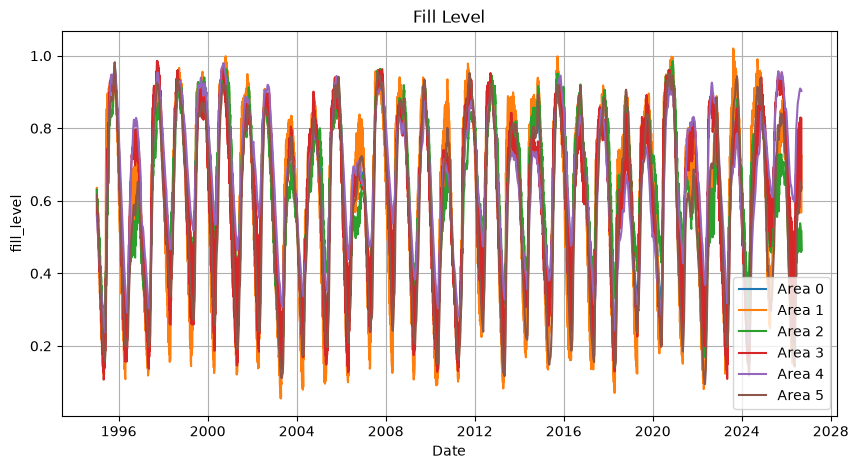

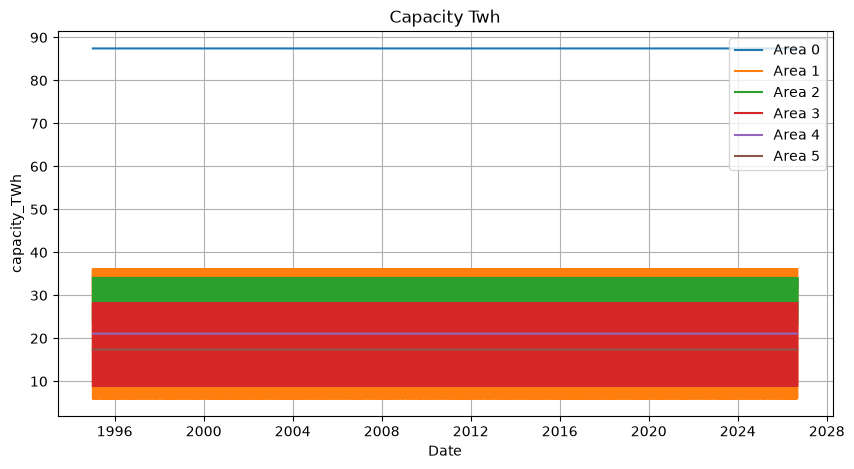

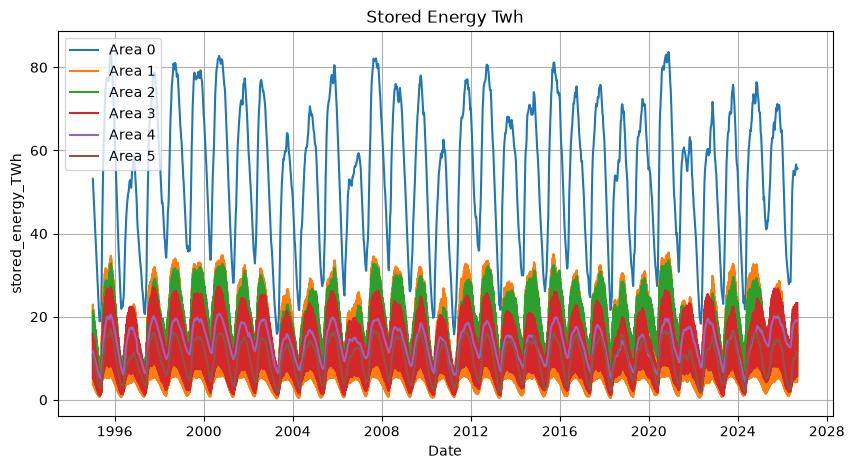

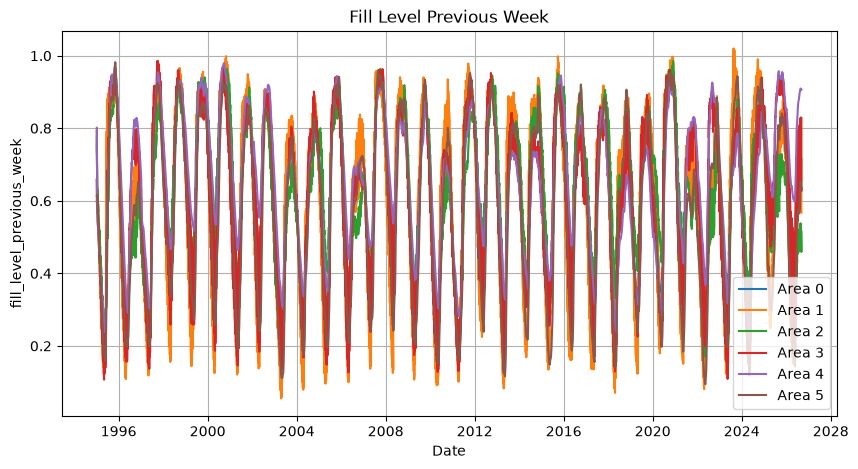

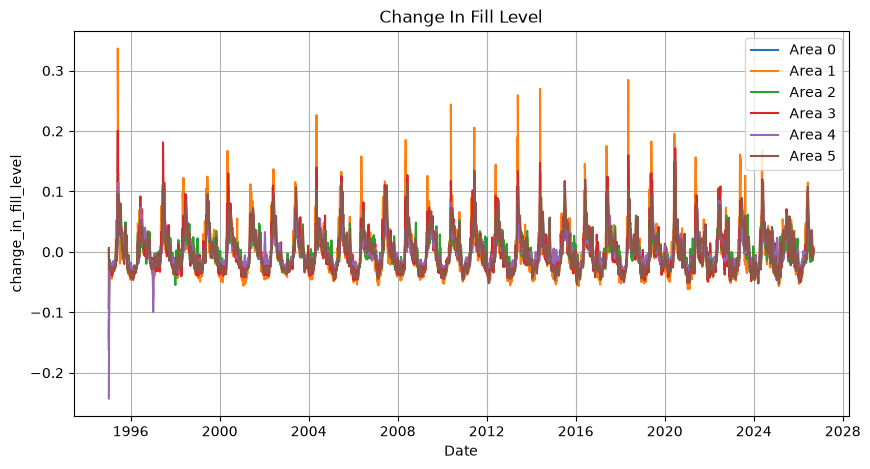

In [6]:
numeric_columns = [
    "fill_level",
    "capacity_TWh",
    "stored_energy_TWh",
    "fill_level_previous_week",
    "change_in_fill_level"
]

for column in numeric_columns:
    plt.figure(figsize=(10, 5))

    for area in sorted(df["area_number"].unique()):
        area_data = df[df["area_number"] == area]

        plt.plot(
            area_data["date"],
            area_data[column],
            label=f"Area {area}"
        )

    plt.xlabel("Date")
    plt.ylabel(column)
    plt.title(column.replace("_", " ").title())
    plt.legend()
    plt.grid(True)
    plt.show()

## 6. Visualizing all numerical columns together

Since the numerical variables have different units and scales, they are normalized before being plotted together. This makes it possible to compare their development over time in a single figure.

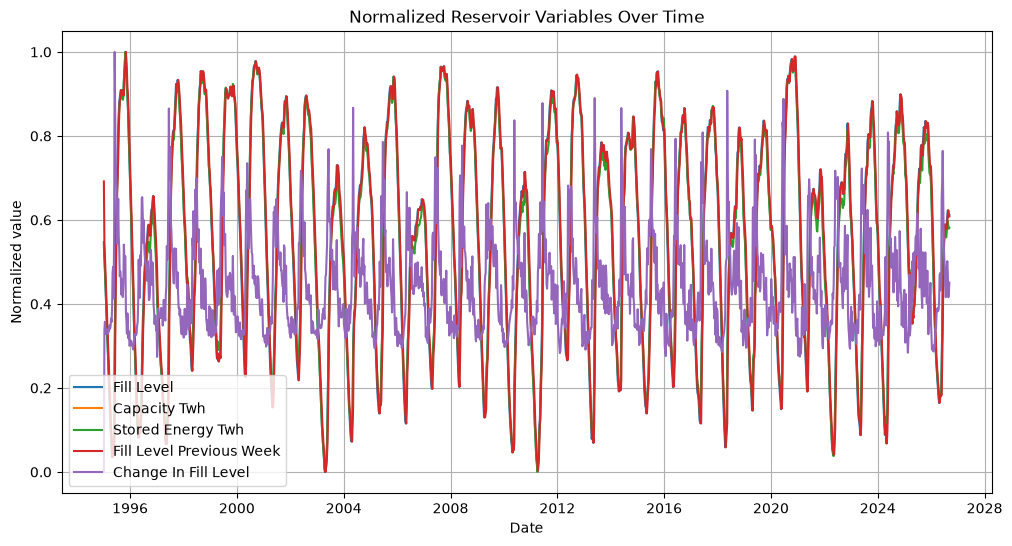

In [7]:
columns_to_plot = [
    "fill_level",
    "capacity_TWh",
    "stored_energy_TWh",
    "fill_level_previous_week",
    "change_in_fill_level"
]

plot_data = df.groupby("date")[columns_to_plot].mean()

# Normalize all variables to a scale from 0 to 1
normalized_df = (plot_data - plot_data.min()) / (plot_data.max() - plot_data.min())

plt.figure(figsize=(12, 6))

for column in normalized_df.columns:
    plt.plot(
        normalized_df.index,
        normalized_df[column],
        label=column.replace("_", " ").title()
    )

plt.xlabel("Date")
plt.ylabel("Normalized value")
plt.title("Normalized Reservoir Variables Over Time")
plt.legend()
plt.grid(True)
plt.show()

## 7. Development log

The Jupyter Notebook was developed step by step by first importing and exploring the reservoir dataset. The original Norwegian column names were translated into clear English names to improve readability. The dataset was then inspected to understand its structure, variables and data types.

The numerical reservoir variables were visualized individually over time. Since the dataset contains several reservoir areas, the areas were plotted separately within each figure to avoid connecting observations from different areas. Finally, the numerical variables were normalized to a common scale from 0 to 1 and plotted together, making variables with different units and scales easier to compare.

During development, the visualizations were adjusted when the initial plots combined observations from different reservoir areas and produced misleading lines. The final plots therefore distinguish between the individual areas.

## 8. AI usage

AI tools were used as support during the development of this project. ChatGPT was used to help interpret the assignment requirements, structure the Jupyter Notebook, and troubleshoot errors.

The suggested code was tested and adjusted during development. For example, the initial visualizations connected observations from different reservoir areas, which resulted in misleading plots. The plotting approach was therefore changed to separate the reservoir areas. AI was also used to suggest an approach for normalizing variables with different scales before plotting them together.

The final implementation was reviewed and tested in the local development environment.

## 9. Project links

GitHub repository  
To be added

Streamlit application  
To be added